**TJ Smith**

**Part 1**

**1.** We need it to be a designed experiment with randomly assigned stores in order to remove confounding variables and to control the number of stores we are testing.\
**2.** The Experimental Unit is LocationID, the Treatment is Promotion, and the Outcome is SalesInThousands\
**3.** This is an Inference problem. We are trying to see if our data shows that sales is affected by promotional treatment, which is a how and potentially why question (both of which point to the idea of inference). If this was a Prediction question we would be asking about what future data would look like and what sales amounts would be based on promotional method.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv('WA_Marketing-Campaign.csv')
df


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81
...,...,...,...,...,...,...,...
543,10,Large,919,2,1,4,64.34
544,10,Large,920,14,2,1,50.20
545,10,Large,920,14,2,2,45.75
546,10,Large,920,14,2,3,44.29


**Part 2**\
**1.**

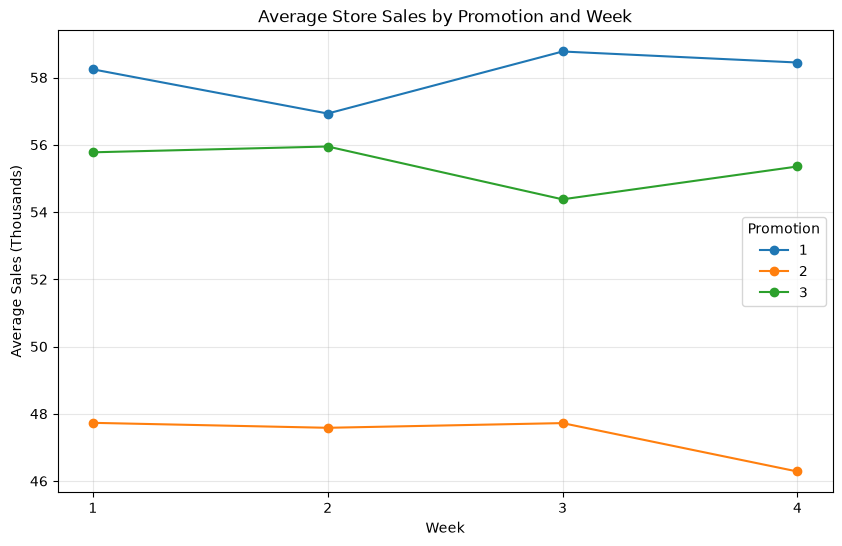

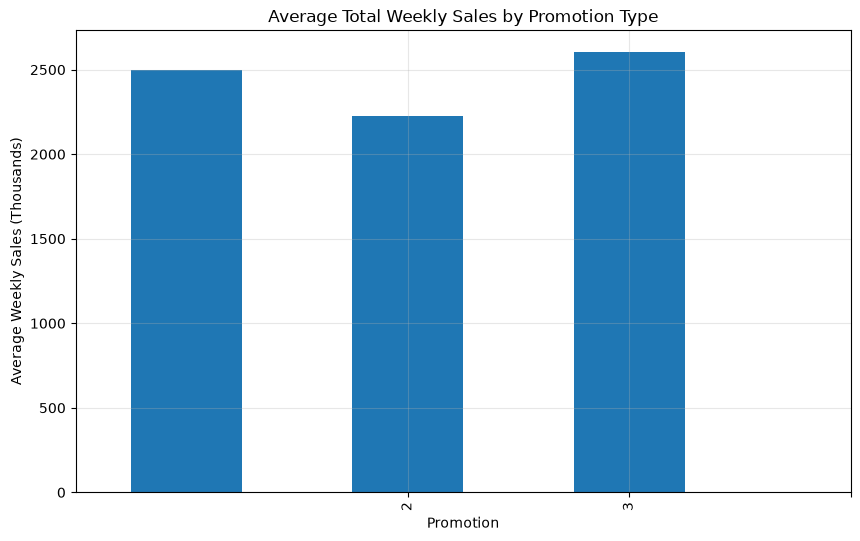

In [5]:
avg_weekly_sales = (df.groupby(["week", "Promotion"], as_index=False)["SalesInThousands"].mean())

avgslwkdf = avg_weekly_sales.pivot(index="week",columns="Promotion", values="SalesInThousands")

avgwekslplot = avgslwkdf.plot(kind="line", marker = 'o', figsize=(10, 6))

avgwekslplot.set_title("Average Store Sales by Promotion and Week")
avgwekslplot.set_xlabel("Week")
avgwekslplot.set_ylabel("Average Sales (Thousands)")
avgwekslplot.set_xticks([1,2,3,4])
avgwekslplot.legend(title="Promotion")
avgwekslplot.grid(True, alpha=0.3)
plt.show()


avgtotalsalesperweek = df.groupby(['week','Promotion'],as_index = False)['SalesInThousands'].sum()
avgtotsalesperweekpiv = avgtotalsalesperweek.pivot(index = 'Promotion',columns = 'week',values = 'SalesInThousands')
avgsalesdf = pd.DataFrame(avgtotsalesperweekpiv.mean(axis = 1))

avgwkslplt = avgsalesdf.plot(kind ='bar',figsize = (10,6))

avgwkslplt.set_title("Average Total Weekly Sales by Promotion Type")
avgwkslplt.set_ylabel('Average Weekly Sales (Thousands)')
avgwkslplt.set_xlabel('Promotion')
avgwkslplt.set_xticks([1,2,3])
avgwkslplt.get_legend().remove()
avgwkslplt.grid(True, alpha=0.3)

plt.show()

**2.** These visualizations suggest that Promotion 1 performs better than Promotion 3, which performs better than Promotion 2; in terms of sales per store. However, we can see that Promotion 3 performed better in total sales across all stores, with Promotion 1 in second place, and Promotion 2 in last.
We can see in terms of variation that Promotion 1 showed an overall upward trend over the 4 weeks, while Promotion 2 had a noticeable downward trend in the last week, and Promotion 3 had a slight downward trend over the weeks.

**3.** No we cannot assume that one promotion caused higher sales as we do not have a control variable to compare against, and we do not know if the lift is statistically significant or can be accounted for by random chance. Further statistical analysis is necessary.

**Part 3**

**1.** In the context of this experiment, theta represents the total average change in weekly sales between Promotion 2 and Promotion 1. Theta>0 would indicate that Promotion 2 performed better on average, Theta = 0 would indicate that Promotion 1 and 2 performed equally on average, and Theta<0 would indicate that Promotion 1 performed better on average.\
\
**2.**

In [54]:
df3 = df.groupby(['Promotion','week'],as_index=False)['SalesInThousands'].mean()
df3p = df3.pivot(index = 'week',columns = 'Promotion',values = 'SalesInThousands')
df3avg = df3p.mean(axis=0)
theta = df3avg[2]-df3avg[1]
print(f'theta_hat = {theta:.5f}')

theta_hat = -10.76960


**3.** theta_hat indicates that Promotion 1 performed an average of $10,769.60 better per store in weekly sales than Promotion 2.\
\
**4.**

In [59]:
rng = np.random.default_rng(4222002)
B = 5000

pmt1 = df.loc[df['Promotion']==1,['SalesInThousands']]
pmt2 = df.loc[df['Promotion'] ==2,['SalesInThousands']]

boot_avg_sale_diff = np.empty(B)

for b in range(B):
    promotion1 = rng.choice(
        pmt1,
        size=len(pmt1),
        replace=True
    )
    promotion2 = rng.choice(
        pmt2,
        size=len(pmt2),
        replace=True
    )
    boot_avg_sale_diff[b] = promotion2.mean()-promotion1.mean()

lower, upper = np.percentile(boot_avg_sale_diff,[2.5,97.5])
print(f'95% bootstrap CI:[${lower:.5f}k, ${upper:.5f}k]')

95% bootstrap CI:[$-14.10469k, $-7.47949k]


**5.** This CI indicates that we are 95% confident that any random sample average weekly sales per store for Promotion 2 will perform between 14,104.69 and 7,479.49 dollars worse than Promotion 1 will.

**6.** A CI captures a range of possible values for a given random sample parameter (in this case the mean) with a confidence indicating how likely a random sample is to fall within that range. This means that while 0 may fall within the CI, it does not necessarily indicate that the population parameter we are estimating to be 0, it only means that if we took a random sample, it is within our 95% confidence range for a samples mean to be 0. In this case, if 0 were in the CI, it would mean that if we took a random sample of stores and found the average weekly sales, it is possible a store would have 0 weekly sales - however that does not mean that the population mean weekly sales we are approximating with all of our sample means is 0.

**Part 4**

**1.** No there is not evidence that Promotion 2 increases sales relative to Promotion 1.\
\
**2.** No there is not evidence that the increase is at least $2,000 per week. The CI contains only negative values (indicating that Promotion 1 performs better), and these values fall between -14k and -7.5k. 2k is not within this range.

**3.** Keep Promotion 1 is my reccomendation. I reccomend this because we are 95% sure that Promotion 1 will perform between 7,479.49 and 14,104.69 better than Promotion 2 will given a random sampling of stores. 

**Part 5**

Written using AI:

In [67]:
from scipy.stats import f_oneway

# Create one sales array for each promotion type
promotion_groups = [
    group["SalesInThousands"].dropna()
    for _, group in df.groupby("Promotion")
]

promotion_labels = df["Promotion"].dropna().unique()

# Run the one-way ANOVA
f_statistic, p_value = f_oneway(*promotion_groups)

print("Promotion types:", promotion_labels)
print("F-statistic:", f_statistic)
print("p-value:", p_value)

Promotion types: [3 2 1]
F-statistic: 21.953485793080674
p-value: 6.765849261408834e-10


**1.** Our null hypothesis is saying that the population mean sales per week is the same for all three promotions.\
\
**2.** The next natural step to explore would be to compare the bootstrapped 95% CI's for each promotion type to determine which seems to perform with the highest weekly sales.\
\
**3.** When we conduct multiple variance analysis with a given confidence, we take the risk of a false positive multiple times in a row which in effect raises the chance of that error higher than our 95% Confidence would indicate.

**Part 6**

**1.** This is now a prediction problem because we are no longer asking about how the promotions have affected sales, we are now asking what sales will be next week given the promotions. We are now trying to predict a future data set rather than looking at the implications of a known data set.\
\
**2.** Market Size, Promotion Type, and Age of Store would be useful predictors of sales because a larger market size likely brings in greater sales, different promotions will have a differing effect upon sales, and the age of the store may indicate a greater presence in the area resulting in more customers and therefore more sales.\
\
**3.** You would evaluate whether a predictive model is successful by predicting the next weeks data, then collecting the true data, and comparing them to one another to see how close the model approximated reality. This is different from what we were trying to accomplish because this focuses on future performance and results to evaluate whether our model is useful, whereas we were focusing on past performance and results to determine which promotion type had a greater effect upon sales.